# NovaRetail+ Customer Behavior and Revenue Drivers


**Portfolio project | Exploratory correlation analysis**

This notebook examines which customer behavior factors are most strongly associated with the annual revenue generated for NovaRetail+. It combines exploratory data analysis, visual diagnostics, and correlation methods selected according to variable type.

> **Important:** Associations are interpreted as non-causal. Revenue is not equivalent to profitability.


NovaRetail+ is an e-commerce platform in Latin America with millions of users.

For the end of 2024, the **Growth and Retention** team aims to answer:

**Which customer behavior factors are most strongly associated with the annual revenue generated?**

> This project is an **exploratory correlational analysis**.  
> **Correlation ≠ causation.**


## Section 1 - Load and Explore the Dataset


In this section, we validate:
- that the dataset loads correctly
- data types
- missing values / general ranges

Before analyzing correlations, we first need to understand the data landscape.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr, chi2_contingency


### Load Dataset


In [2]:
# Load the dataset and inspect the data
df = pd.read_csv('data/novaretail_comportamiento_clientes_2024.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Dataset Description

The dataset contains the following columns:

- `id_cliente` — Unique customer identifier.
- `edad` — Customer age.
- `nivel_ingreso` — Estimated annual income of the customer.
- `visitas_mes` — Number of visits to the app or website during the month.
- `compras_mes` — Number of purchases made during the month.
- `gasto_publicidad_dirigida` — Advertising spend allocated to the customer.
- `satisfaccion` — Customer satisfaction rating on a scale from 1 to 5.
- `miembro_premium` — Indicates whether the customer has a premium subscription (1) or not (0).
- `abandono` — Indicates whether the customer left the platform (1) or not (0).
- `tipo_dispositivo` — Type of device used by the customer (mobile, desktop, or tablet).
- `region` — Customer's geographic region (north, south, west, or east).
- `ingreso_anual` — Annual revenue generated by the customer for the company.

The primary metric for the analysis is `ingreso_anual`, used to assess the economic contribution of customers.


In [3]:
# Display the first 5 rows
df.head()


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Section 2 - Prepare Data and Document Assumptions


### Exploration and Cleaning


#### Initial Data Exploration
The dataset contains **15,000 records** and **12 columns**, with no missing values.

**Numerical variables**  
The following numerical columns are identified:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `miembro_premium`
- `abandono`
- `ingreso_anual`

Most of these variables have appropriate data types.  
The `edad` column should be converted from `float64` to integer because it represents whole years and contains no decimal values.

**Binary variables**  
The following columns represent binary variables:
- `miembro_premium`
- `abandono`

Both are coded as 0 and 1 and **do not require additional transformation**.

**Categorical variables**  
The following categorical columns are identified:
- `id_cliente`
- `tipo_dispositivo`
- `region`

These variables are correctly defined and do not require additional transformation.


In [4]:
# Correct the data type
df['edad'] = df['edad'].astype(int)


In [5]:
# Verify changes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explore Numerical Variables


In [6]:
# Descriptive statistics for numerical variables
df.describe()


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


### Initial Assessment of Numerical Variables


* `edad` — The central 50% of users are between 30 and 46 years old. The average age is 38.3 years, with a minimum of 18 and a maximum of 75.

* `nivel_ingreso` — The average estimated annual income is 30,019.7 and the median is 30,023.7. The central 50% of customers fall between 23,127.1 and 36,768.4, with a minimum of 8,000 and a maximum of 74,790.8. The distance between the central values and the extremes suggests reviewing the potential presence of outliers later.

* `visitas_mes` — Customers make an average of 10 monthly visits to the app or website, with a median of 10. The central 50% record between 8 and 12 visits per month, with a minimum of 1 and a maximum of 25. The extreme values suggest reviewing the potential presence of outliers later.

* `compras_mes` — Customers make an average of 1.2 purchases per month, with a median of 1. Seventy-five percent of customers make up to 2 purchases per month. Some customers make 0 purchases, while the maximum is 8 purchases per month.

* `gasto_publicidad_dirigida` — Average targeted advertising spend per customer is 20.15 and the median is 19.73. The central 50% falls between 12.31 and 27.29, with a minimum of 0 and a maximum of 75.51. The maximum value suggests reviewing the potential presence of outliers later.

* `satisfaccion` — Average customer satisfaction is 3.6 on a scale from 1 to 5, matching a median of 3.6. The central 50% of ratings fall between 3.1 and 4.1.

* `miembro_premium` — Because this is a binary variable coded as 0 and 1, its mean of 0.139 indicates that approximately 13.9% of customers belong to the premium segment.

* `abandono` — Because this is a binary variable coded as 0 and 1, its mean of 0.151 indicates that approximately 15.1% of customers have left the platform.

* `ingreso_anual` — Annual revenue generated per customer has a mean of 36.59 and a median of 30.71. The central 50% falls between 0 and 58.22, with a minimum of 0 and a maximum of 244.69. The difference between the mean and median, together with the observed maximum, suggests further exploration of the distribution and the potential presence of outliers.


#### Explore Binary Variables


In [7]:
# Verify that each column contains only two possible values
df[['miembro_premium', 'abandono']].apply(pd.Series.value_counts)


,miembro_premium,abandono
0,12911,12739
1,2089,2261


### Initial Assessment of Binary Variables


- `miembro_premium` — There are 12,911 non-premium users and 2,089 premium users, representing approximately 86.1% and 13.9% of the total, respectively.
- `abandono` — 12,739 users did not leave the platform, while 2,261 did, representing approximately 84.9% and 15.1% of the total, respectively.


#### Explore Categorical Variables


In [8]:
# Verify the number of unique values per categorical variable
df[['id_cliente', 'tipo_dispositivo', 'region']].nunique()


id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [9]:
# Explore categorical variables and their distributions
print(df[['id_cliente', 'tipo_dispositivo', 'region']].describe())
print()
print("Distribution by device type")
print(df['tipo_dispositivo'].value_counts())
print()
print("Distribution by region")
print(df['region'].value_counts())


       id_cliente tipo_dispositivo region
count       15000            15000  15000
unique      15000                3      4
top     CL-100000            móvil  norte
freq            1             9818   4395

Distribution by device type
tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64

Distribution by region
region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


### Initial Assessment of Categorical Variables


- `id_cliente` — Confirmed as a unique customer identifier, with 15,000 unique values for 15,000 records. By nature, it will not be used as a categorical variable for customer segmentation.
- `tipo_dispositivo` — Three device types are identified: mobile, desktop, and tablet. Mobile is the most frequent with 9,818 records, followed by desktop with 3,720 and tablet with 1,462.
- `region` — Four regions are identified. In descending order of frequency, customers are distributed as follows: north with 4,395 records, west with 3,810, south with 3,726, and east with 3,069.


### Assumptions

- The analysis uses **the entire available dataset**.
- The data contain no identified errors and are correctly typed.
- Different coefficients are used depending on the variable types:
  - **Pearson** assumes linear relationships between numerical variables.
  - **Spearman** evaluates monotonic relationships and does not require normality.
  - **Point-biserial** is used for numerical–binary relationships.
  - **Cramér's V** is used for associations between categorical variables.

**Core assumption:**  
This analysis identifies relationships between variables or segments, but does not establish causality.


## Section 3 - Visualizing Relationships

We examine how the numerical variables relate to one another.


### Heatmap


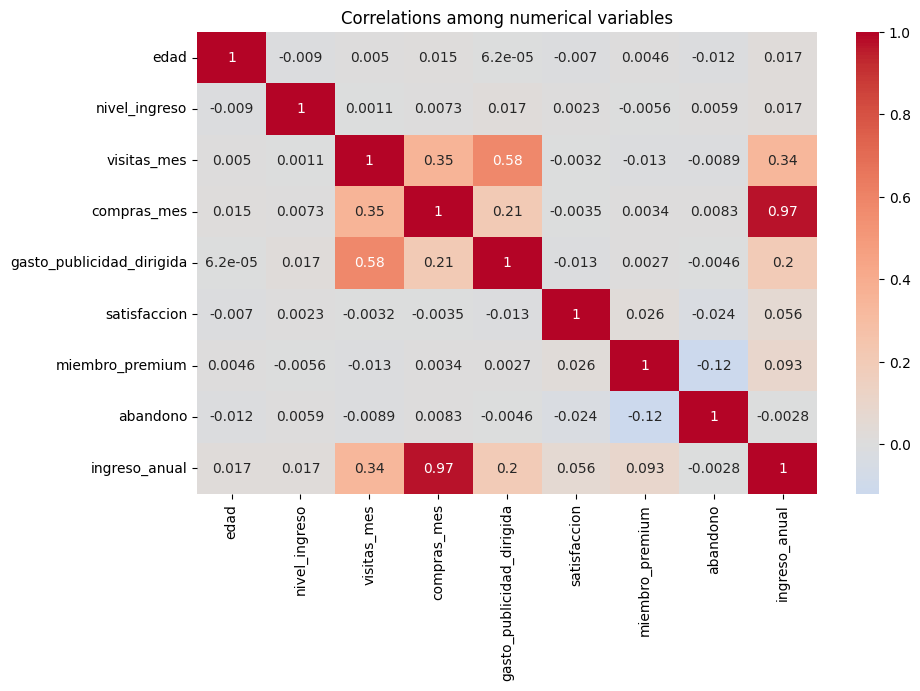

In [10]:
# Visualize the correlation matrix to identify relationships
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlations among numerical variables')
plt.show()


### General Observations (Heatmap)

- `compras_mes` has a positive correlation of 0.35 with `visitas_mes`, suggesting some association between greater platform activity and the number of purchases.
- `gasto_publicidad_dirigida` has a positive correlation of 0.58 with `visitas_mes`, making it one of the most notable relationships outside the target variable.
- `gasto_publicidad_dirigida` also shows a weaker positive correlation of 0.21 with `compras_mes`.
- A weak negative correlation of -0.12 is observed between `miembro_premium` and `abandono`. Their remaining linear relationships are close to zero.

Observations regarding `ingreso_anual`  
- The strongest relationship is with `compras_mes`, with a positive correlation of 0.97, indicating a very strong linear association with annual revenue generated.
- `visitas_mes` has a positive correlation of 0.34, considerably lower than the one observed with purchases.
- `gasto_publicidad_dirigida` has a positive correlation of 0.20, indicating a weak association with annual revenue.
- The remaining variables have correlations very close to zero with `ingreso_anual`, so they do not show a relevant linear association in this initial analysis.


### General Scatterplot


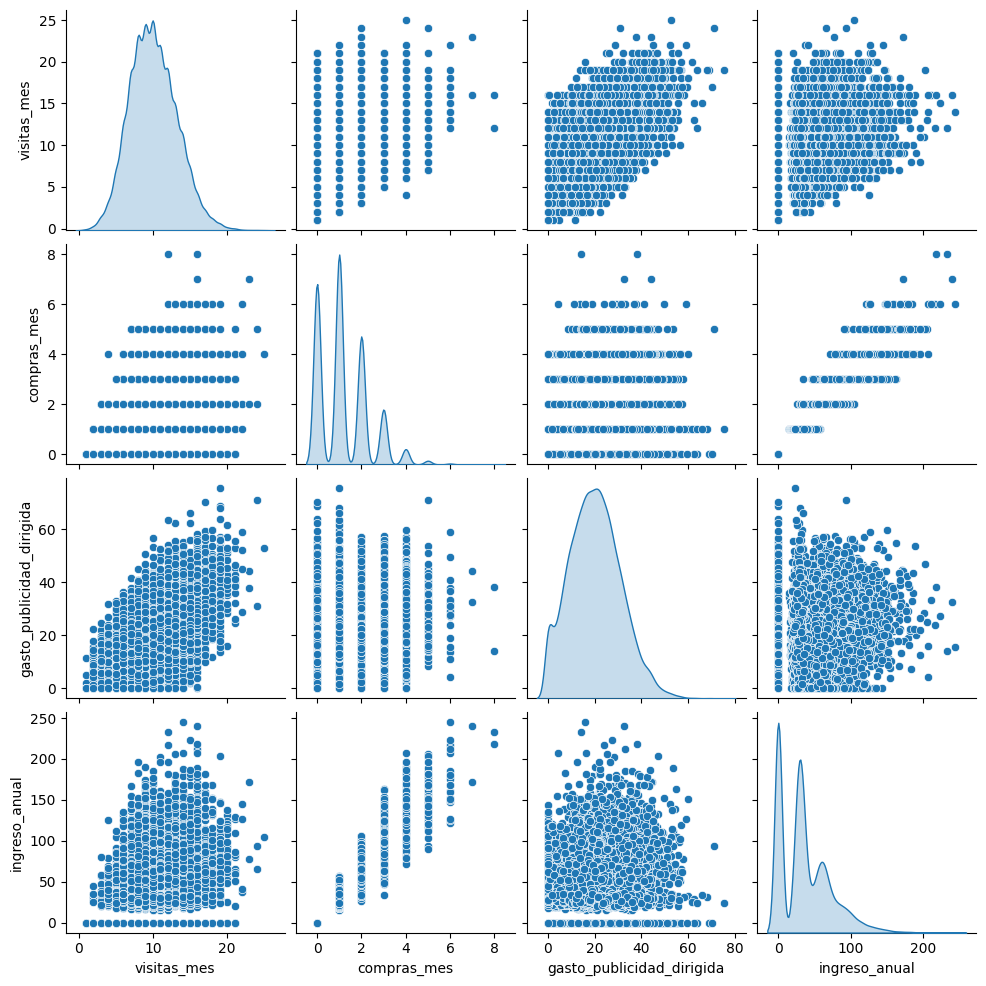

In [11]:
sns.pairplot(
    df[['visitas_mes',
        'compras_mes',
        'gasto_publicidad_dirigida',
        'ingreso_anual']],
    diag_kind='kde'
)

plt.show()


- Given the different correlations identified in the heatmap, a general pairplot is created to visualize the shape and dispersion of the relationships among the main variables.
- Regarding the target variable, `ingreso_anual`, the strongest association is visually confirmed with `compras_mes` (0.97), showing a very pronounced positive pattern. `visitas_mes` shows a considerably weaker positive relationship (0.34) with greater dispersion.
- The relationship between `gasto_publicidad_dirigida` and `ingreso_anual` is weak (0.20) and widely dispersed. Some extreme values are also visible and should be examined later before classifying them as outliers.
- `gasto_publicidad_dirigida` and `visitas_mes` show a moderate positive relationship (0.58). The upward pattern is visible, although there is dispersion among the observations.


### Scatterplots for Key Pairs


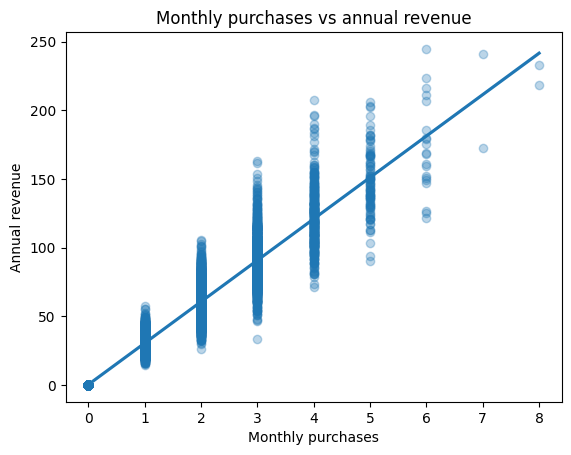

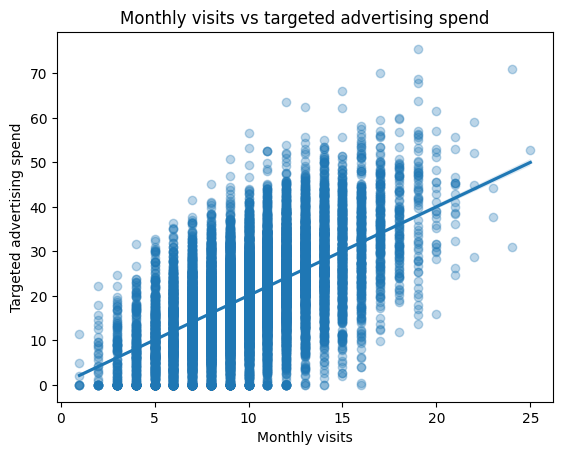

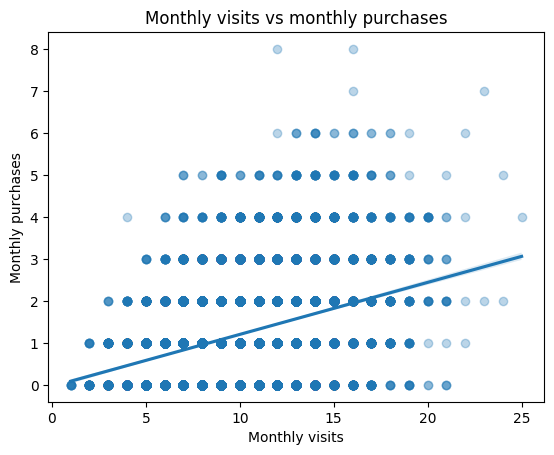

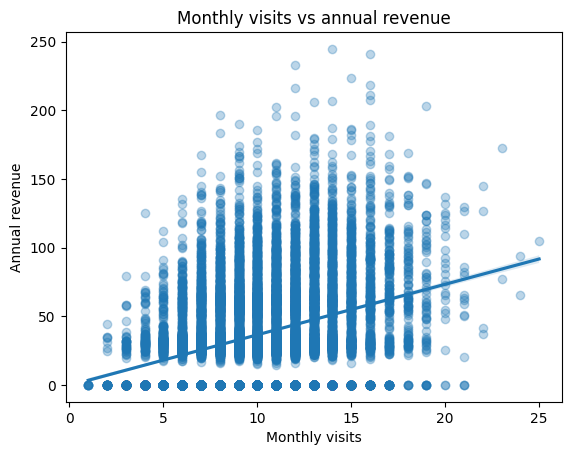

In [12]:
# Visualize pairs of variables with moderate or strong relationships

# 1. Monthly purchases vs annual revenue
sns.regplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual',
    scatter_kws={'alpha': 0.3}
)

plt.title('Monthly purchases vs annual revenue')
plt.xlabel('Monthly purchases')
plt.ylabel('Annual revenue')
plt.show()


# 2. Monthly visits vs targeted advertising spend
sns.regplot(
    data=df,
    x='visitas_mes',
    y='gasto_publicidad_dirigida',
    scatter_kws={'alpha': 0.3}
)

plt.title('Monthly visits vs targeted advertising spend')
plt.xlabel('Monthly visits')
plt.ylabel('Targeted advertising spend')
plt.show()


# 3. Monthly visits vs monthly purchases
sns.regplot(
    data=df,
    x='visitas_mes',
    y='compras_mes',
    scatter_kws={'alpha': 0.3}
)

plt.title('Monthly visits vs monthly purchases')
plt.xlabel('Monthly visits')
plt.ylabel('Monthly purchases')
plt.show()


# 4. Monthly visits vs annual revenue
sns.regplot(
    data=df,
    x='visitas_mes',
    y='ingreso_anual',
    scatter_kws={'alpha': 0.3}
)

plt.title('Monthly visits vs annual revenue')
plt.xlabel('Monthly visits')
plt.ylabel('Annual revenue')
plt.show()


### Initial Observations (Scatterplots)

**Monthly purchases vs annual revenue**

* Very strong positive linear direction.
* Low dispersion around the trend.
* Some extreme values are visible and should be evaluated later before classifying them as outliers.

**Monthly visits vs targeted advertising spend**

* Moderate positive linear direction.
* Medium dispersion.
* Some extreme values are visible and should be evaluated later.

**Monthly visits vs monthly purchases**

* Weak positive linear direction.
* High dispersion.
* The banded distribution reflects the discrete nature of `compras_mes`.
* Some extreme values are visible and should be evaluated later.

**Monthly visits vs annual revenue**

* Weak positive linear direction.
* High dispersion.
* The relationship is considerably weaker than the one observed between `compras_mes` and `ingreso_anual`.
* Some extreme values are visible and should be evaluated later.


## Section 4 - Correlation Coefficients and Numerical Evidence

This section reports coefficients that support the patterns observed visually, using the appropriate method for each variable type.


### Pearson / Spearman


In [13]:
# Calculate correlations between relevant variables

# 1. Monthly purchases vs annual revenue
pearson_compras_ingreso = df['compras_mes'].corr(
    df['ingreso_anual'],
    method='pearson'
)

print('Monthly purchases vs annual revenue')
print(f'Pearson: {pearson_compras_ingreso:.3f}')
print()


# 2. Monthly visits vs targeted advertising spend
pearson_visitas_publicidad = df['visitas_mes'].corr(
    df['gasto_publicidad_dirigida'],
    method='pearson'
)

print('Monthly visits vs targeted advertising spend')
print(f'Pearson: {pearson_visitas_publicidad:.3f}')
print()


# 3. Monthly visits vs monthly purchases
pearson_visitas_compras = df['visitas_mes'].corr(
    df['compras_mes'],
    method='pearson'
)

spearman_visitas_compras = df['visitas_mes'].corr(
    df['compras_mes'],
    method='spearman'
)

print('Monthly visits vs monthly purchases')
print(f'Pearson:  {pearson_visitas_compras:.3f}')
print(f'Spearman: {spearman_visitas_compras:.3f}')
print()


# 4. Monthly visits vs annual revenue
pearson_visitas_ingreso = df['visitas_mes'].corr(
    df['ingreso_anual'],
    method='pearson'
)

spearman_visitas_ingreso = df['visitas_mes'].corr(
    df['ingreso_anual'],
    method='spearman'
)

print('Monthly visits vs annual revenue')
print(f'Pearson:  {pearson_visitas_ingreso:.3f}')
print(f'Spearman: {spearman_visitas_ingreso:.3f}')


Monthly purchases vs annual revenue
Pearson: 0.967

Monthly visits vs targeted advertising spend
Pearson: 0.579

Monthly visits vs monthly purchases
Pearson:  0.354
Spearman: 0.333

Monthly visits vs annual revenue
Pearson:  0.337
Spearman: 0.321


### Correlation Observations

**`compras_mes` vs `ingreso_anual`**

* Very strong positive correlation (`Pearson = 0.967`).
* A highly pronounced linear association is confirmed between the number of monthly purchases and the annual revenue generated.

**`visitas_mes` vs `gasto_publicidad_dirigida`**

* Moderate positive correlation (`Pearson = 0.579`).
* A greater number of monthly visits tends to be associated with higher targeted advertising spend, although with considerable dispersion.

**`visitas_mes` vs `compras_mes`**

* Weak positive correlation (`Pearson = 0.354`; `Spearman = 0.333`).
* Spearman was used as a robustness check because of the observed dispersion and the possible presence of extreme values.
* The similarity between both coefficients suggests that these factors do not materially change the overall direction or magnitude of the association.

**`visitas_mes` vs `ingreso_anual`**

* Weak positive correlation (`Pearson = 0.337`; `Spearman = 0.321`).
* Spearman was used as a robustness check because of the observed dispersion and the possible presence of extreme values.
* The closeness of both coefficients suggests that the conclusion of a weak positive association between the variables remains stable.


### Point-Biserial Correlation


In [14]:
# Calculate correlations between relevant variables
print(pointbiserialr(df['miembro_premium'], df['ingreso_anual']))
print(pointbiserialr(df['abandono'], df['ingreso_anual']))


SignificanceResult(statistic=np.float64(0.09309943961980147), pvalue=np.float64(3.094307615527345e-30))
SignificanceResult(statistic=np.float64(-0.0028239340216171614), pvalue=np.float64(0.7294691719078419))


In [15]:
# Summary of annual revenue by premium segment
premium_summary = df.groupby('miembro_premium')['ingreso_anual'].agg(
    customers='count',
    avg_revenue='mean',
    total_revenue='sum'
)

# Calculate total revenue across all customers
total_revenue_all = premium_summary['total_revenue'].sum()

# Calculate each segment's share of total revenue
premium_summary['revenue_share_pct'] = (
    premium_summary['total_revenue'] / total_revenue_all * 100
).round(2)

# Round average revenue
premium_summary['avg_revenue'] = premium_summary['avg_revenue'].round(2)

premium_summary


,customers,avg_revenue,total_revenue,revenue_share_pct
miembro_premium,,,,
0,12911,35.30,455794.58,83.04
1,2089,44.58,93118.12,16.96


In [16]:
# Prepare data for the charts
premium_plot_data = premium_summary.reset_index()

# Create clear segment labels
premium_plot_data['segment'] = premium_plot_data['miembro_premium'].map({
    0: 'Non-premium',
    1: 'Premium'
})


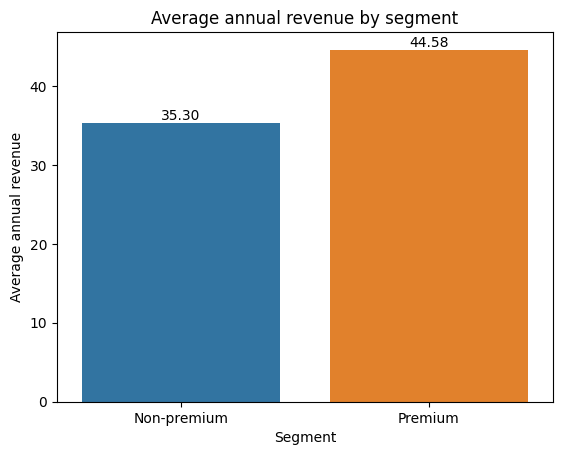

In [17]:
# Chart 1: average annual revenue by segment
ax = sns.barplot(
    data=premium_plot_data,
    x='segment',
    hue='segment',
    legend=False,
    y='avg_revenue'
)

# Display values above the bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='normal'
    )

plt.title('Average annual revenue by segment')
plt.xlabel('Segment')
plt.ylabel('Average annual revenue')
plt.show()


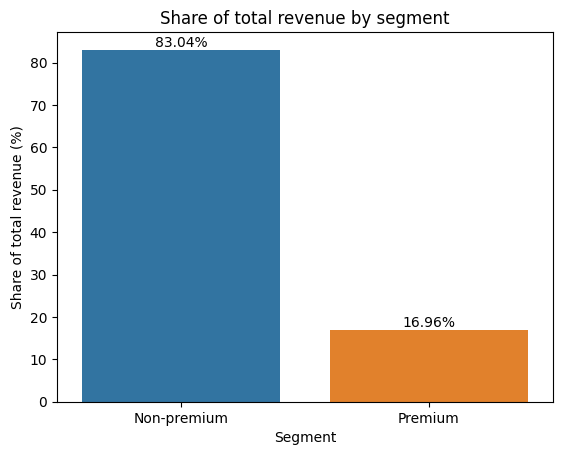

In [18]:
# Chart 2: share of total revenue by segment
ax = sns.barplot(
    data=premium_plot_data,
    x='segment',
    hue='segment',
    legend=False,
    y='revenue_share_pct'
)

# Display values above the bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='normal'
    )

plt.title('Share of total revenue by segment')
plt.xlabel('Segment')
plt.ylabel('Share of total revenue (%)')
plt.show()


### Point-Biserial Observations


**`miembro_premium` and `ingreso_anual`**

- A positive relationship of very low magnitude (`r = 0.093`) is observed between belonging to the premium segment and the annual revenue generated per customer for the company.
- Premium customers generate an average annual revenue of 44.58, compared with 35.30 for non-premium customers, approximately 26% more per customer.
- However, because the premium segment includes only 2,089 customers compared with 12,911 non-premium customers, its total revenue is lower: 93,118.12 versus 455,794.58.
- Premium customers contribute 16.96% of total revenue, while non-premium customers generate 83.04%.
- Premium customers represent approximately 13.9% of the customer base but contribute 16.96% of total revenue, so their economic contribution is proportionally higher than their share of customers.
- Overall, the results indicate that premium membership is weakly associated with higher revenue per customer, while the non-premium segment continues to account for most total revenue because of its much larger size.

**`abandono` and `ingreso_anual`**

- A practically null negative relationship is observed (`r = -0.003`).
- No relevant association is identified between leaving the platform and the annual revenue generated by the customer for the company.


### Cramér's V


In [19]:
# Function to calculate Cramér's V
def cramer_v(df, col1, col2):
    table = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(table)
    n = table.values.sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return v


In [20]:
# Apply Cramér's V to relevant variables
cramers_v_coef = cramer_v(df, 'region', 'tipo_dispositivo')

print('Association between region and device type:')
print(cramers_v_coef)


Association between region and device type:
0.012378338407739397


### Cramér's V Observations
- A **Cramér's V = 0.012** is obtained between `region` and `tipo_dispositivo`, indicating a practically null association between the variables.
- Therefore, no relevant pattern is identified between the customer's region and the type of device used.
- In this dataset, knowing a customer's region provides very little information for anticipating which type of device they use.


## Section 5 - Business Interpretation of Results

Each finding should include:
1) Visual evidence (if applicable)  
2) Numerical evidence  
3) Interpretation (non-causal)  
4) What we cannot conclude  
5) Business implication

---


### Finding 1 — Monthly purchases show a very strong positive association with annual revenue generated per customer.

**Visual evidence:**  
Scatterplot #1: `compras_mes` vs `ingreso_anual`.

**Numerical evidence:**  
Pearson: **0.967**.

**Interpretation:**  
`compras_mes` is the analyzed variable with the strongest association with `ingreso_anual`. Customers who make more purchases tend to generate higher revenue for the company.

**What we cannot conclude:**  
That a higher number of purchases necessarily implies greater profitability, since the dataset does not include costs, margins, discounts, or returns.

**Business implication:**  
Purchase frequency is a relevant indicator of revenue generated, so strategies aimed at increasing repeat purchases should be evaluated, while later complementing the analysis with profitability metrics.


### Finding 2 — Premium customers generate higher average revenue per customer, although non-premium customers account for most total revenue.

**Visual evidence:**  
Bar charts of average annual revenue and share of total revenue by segment. Premium customers show higher average revenue per customer (44.58 vs 35.30), while non-premium customers account for a larger share of total revenue (83.04% vs 16.96%).

**Numerical evidence:**  
Point-biserial correlation between `miembro_premium` and `ingreso_anual`: **0.093**.  
Average revenue: premium **44.58** vs non-premium **35.30**.  
Premium customers represent **13.9%** of the customer base and contribute **16.96%** of total revenue.

**Interpretation:**  
Premium membership has a very weak positive association with annual revenue. However, premium customers generate higher average revenue per customer, while non-premium customers account for most total revenue because the segment is much larger.

**What we cannot conclude:**  
That belonging to the premium segment causes higher annual revenue per customer.

**Business implication:**  
The higher average revenue among premium customers suggests evaluating conversion strategies toward this segment, while keeping in view the importance of the large non-premium customer base in total revenue.


### Finding 3 — Customer activity is related to advertising, purchases, and revenue, although the associations are moderate or weak.

**Visual evidence:**  
Scatterplots #2, #3, and #4.

**Numerical evidence:**  
`visitas_mes` vs `gasto_publicidad_dirigida`: Pearson **0.579**.  
`visitas_mes` vs `compras_mes`: Pearson **0.354** | Spearman **0.333**.  
`visitas_mes` vs `ingreso_anual`: Pearson **0.337** | Spearman **0.321**.  
`gasto_publicidad_dirigida` vs `ingreso_anual`: Pearson **0.20**.

**Interpretation:**  
Monthly visits are moderately associated with targeted advertising spend, but only weakly associated with purchases and annual revenue. Likewise, the direct relationship between advertising spend and revenue is weak.

**What we cannot conclude:**  
That increasing advertising causes more visits, or that a greater number of visits necessarily generates more purchases or higher revenue.

**Business implication:**  
It is worth analyzing which factors convert user activity into purchases and evaluating the economic effectiveness of advertising investment in greater depth.


## Section 6 - Limitations and Next Steps


### **Limitations**

* Correlation ≠ causation. The identified associations do not allow us to conclude that one variable causes changes in another.
* Potential extreme values were identified, but no formal outlier analysis was performed to determine their impact.
* `ingreso_anual` measures revenue generated, but it does not allow profitability to be assessed because costs, margins, discounts, and returns are not available.
* The analysis was conducted mainly on the full customer base, so some relationships may differ between premium and non-premium customers.
* There is not enough information to analyze the complete funnel between visits and purchases.

### **Next Steps**

**Deepen segmentation**

* Compare the main correlations between premium and non-premium customers.
* Analyze differences by `edad` ranges, `region`, and `tipo_dispositivo`.

**Analyze conversion and profitability**

* Incorporate additional funnel stages to identify where conversion is lost between visits and purchases.
* Incorporate ticket size, costs, margins, discounts, and returns to determine whether greater purchase frequency also implies higher profitability.

**Validate the robustness of the results**

* Formally identify outliers and evaluate their effect on the correlations.
* Compare the overall results with those obtained after segmenting the customer base.
